In [12]:
from fastai.vision.all import * 

In [4]:
import torch.nn as nn
import torch

In [44]:
from make import load_secondary_data
spec, labels = load_secondary_data()

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall


In [45]:
from validation_util import split

valid, valid_labels = split(spec, int(len(spec) * 0.1), labels=labels)

In [46]:
class CNN1D(nn.Module):
    def __init__(self, n_classes: int, target_hw=(112, 112)):
        super().__init__()
        self.target_hw = target_hw
        
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
        )
        
        # Infer flattened size automatically
        with torch.no_grad():
            dummy = torch.zeros(1, 3, *self.target_hw)
            out = self.feature_extractor(dummy)
            self.flattened_size = out.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flattened_size, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, n_classes)   # raw logits for CrossEntropyLoss
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        return self.classifier(x)

In [47]:
# constants you can tweak once
FLOOR_DB   = -5.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [48]:
import matplotlib.pyplot as plt
import numpy as np

In [49]:
def get_x(i : int):
        arr = spec[i]

        # If spectrogram is multi-channel, convert to grayscale first
        if len(arr.shape) == 3:
                arr = np.mean(arr, axis=-1)  # average across channels
        
        #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
        
        # Apply colormap to convert grayscale to color
        # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
        colormap = plt.get_cmap('hot')  # or try 'plasma', 'magma', 'jet'
        arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
        
        # Convert RGBA to RGB (drop alpha channel)
        arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
        
        # Convert to PyTorch tensor with correct channel ordering
        t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
        
        # Resize image
        t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
        
        return TensorImage(t_resized.squeeze(0))  # (3, H, W)

def get_y(i):
    return labels[i]

In [50]:
block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=get_x,
    get_y=get_y,
)

In [51]:
items = list(range(len(spec)))   # or `range(N)`
dls = block.dataloaders(items, bs=12)

In [52]:
model = CNN1D(n_classes=3)

In [53]:
learner = Learner(dls, model, loss_func=CrossEntropyLossFlat(), metrics=accuracy)

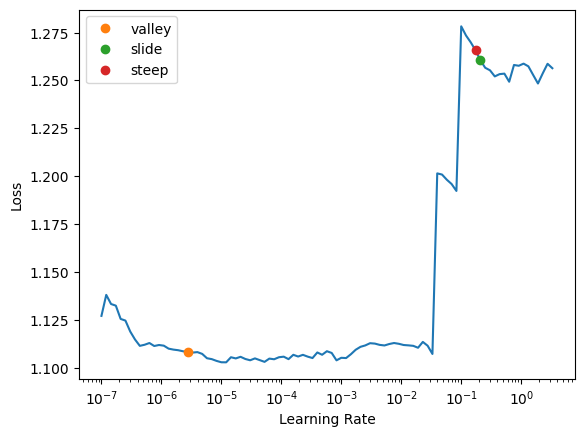

In [54]:
lr = learner.lr_find(suggest_funcs=(valley,slide,steep))

In [55]:
learner.fine_tune(20)

epoch     train_loss  valid_loss  accuracy  time    
0         1.134202    1.109108    0.333333  00:00                                        
epoch     train_loss  valid_loss  accuracy  time    
0         1.082693    1.073970    0.333333  00:00                                         
1         1.059638    1.061256    0.500000  00:00                                         
2         1.019542    1.003030    0.500000  00:00                                         
3         0.933709    0.759630    0.703704  00:00                                         
4         0.819201    0.613367    0.814815  00:00                                         
5         0.701281    0.548203    0.768519  00:00                                         
6         0.640889    0.532654    0.796296  00:00                                         
7         0.565485    0.439400    0.796296  00:00                                         
8         0.511290    0.381705    0.861111  00:00                           

In [56]:
learner.unfreeze()

In [57]:
learner.fit_one_cycle(30, lr.valley)

epoch     train_loss  valid_loss  accuracy  time    
0         0.228300    0.327629    0.861111  00:00                                         
1         0.226133    0.327570    0.861111  00:00                                         
2         0.240483    0.327450    0.861111  00:00                                         
3         0.247736    0.327226    0.861111  00:00                                         
4         0.252936    0.327396    0.861111  00:00                                         
5         0.255013    0.327266    0.861111  00:00                                         
6         0.241598    0.327161    0.851852  00:00                                         
7         0.226692    0.327506    0.842593  00:00                                         
8         0.215953    0.327950    0.842593  00:00                                         
9         0.227455    0.327761    0.851852  00:00                                          
10        0.195600    0.328272    0.

In [58]:
dir = Path('./models')

learner.path = dir

learner.export('hybrid.pkl')

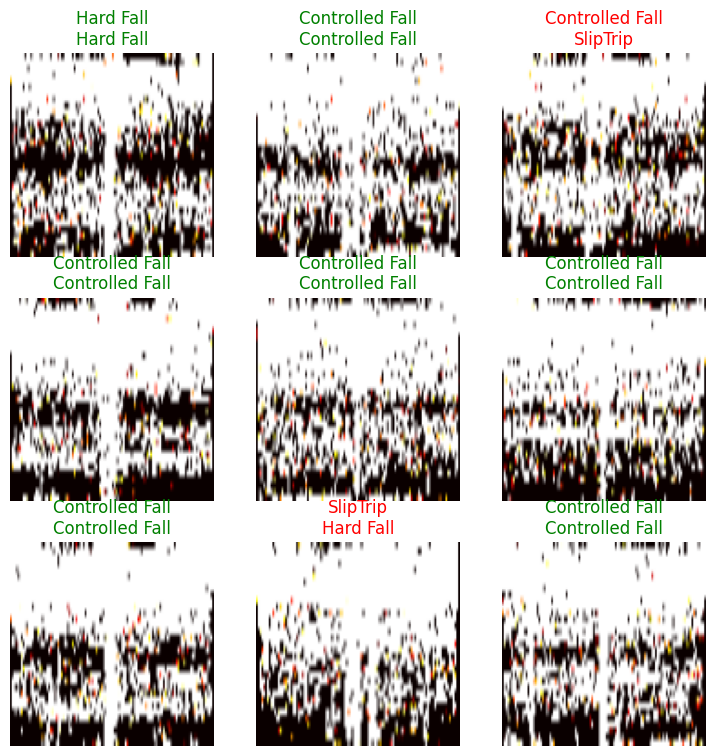

In [59]:
learner.show_results()

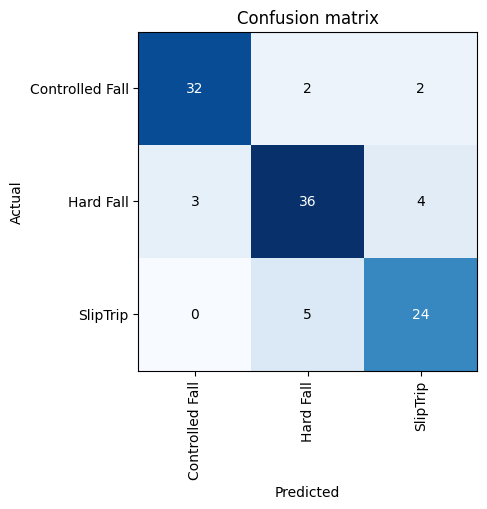

In [60]:
inter_plot = ClassificationInterpretation.from_learner(learner)
inter_plot.plot_confusion_matrix(figsize=(5,5))

In [61]:
def get_x_test(i):
    arr = valid[i]

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr.shape) == 3:
        arr = np.mean(arr, axis=-1)  # average across channels
    
    #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('hot')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)


def get_y_test(i):
    return valid_labels[i]

In [62]:
learner.validate()

(#2) [0.32598304748535156,0.8518518805503845]

In [63]:
def get_y_pred(learner: Learner, val_set : list):
    y_pred = []
    y_test = []
    
    for i in range(len(val_set)):
        y_pred.append(learner.predict(get_x_test(i))[0])
        y_test.append(get_y_test(i))
    return y_pred, y_test 

In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [65]:
y_pred, y_test = get_y_pred(learner, valid)

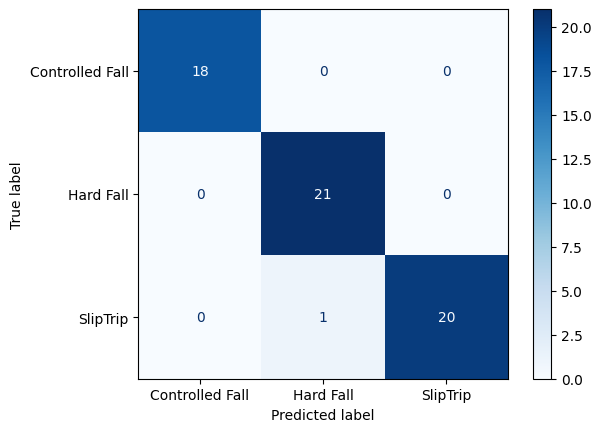

In [66]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=dls.vocab)
disp.plot(cmap="Blues")  # customize as you like
plt.show()

In [67]:
accuracy_score(y_test, y_pred)

0.9833333333333333

In [68]:
precision_score(y_test, y_pred, average='weighted')

0.9840909090909091

In [69]:
recall_score(y_test, y_pred, average="weighted")

0.9833333333333333

In [70]:
f1_score(y_test, y_pred, average="weighted")

0.9833238797504253